## OptimESM Work Package 5: Ocean Circulation Figures

### Description:

Notebook containing plots of ocean circulation diagnostics for OptimESM idealised experiments.

### Created By:

Ollie Tooth (oliver.tooth@noc.ac.uk)

In [1]:
# -- Import dependencies -- #
import glob
import cftime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# -- Update matplotlib defaults -- #
plt.rcParams.update({
    # Figure
    "figure.figsize": (6.5, 4.0),          # Good for reports (inches)
    "figure.dpi": 500,                     # High resolution for raster export
    "savefig.dpi": 500,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,

    # Fonts
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Axes
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.3,

    # Lines
    "lines.linewidth": 1.8,
    "lines.markersize": 5,

    # Legend
    "legend.frameon": False,
})


### **Utility Functions**

In [2]:
def open_diagnostic_dataset(filepath: str, offset: int = 0):
    """
    Open NEMO Pipeline Diagnostic Dataset.

    Parameters
    ----------
    filepath : str
        Filepath to NEMO Pipeline diagnostics stored in local netCDF file.
    offset : int
        Offset used to adjust (add) time_counter coordinate.

    Returns
    -------
    ds : xr.Dataset
    """
    # Define CF-timecoder:
    time_coder = xr.coders.CFDatetimeCoder(time_unit="s")
    # Open diagnostic netCDF dataset:
    ds = xr.open_dataset(filepath, decode_times=time_coder)

    # Update time_counter coord using cftime:
    new_time_counter = [
        cftime.Datetime360Day(t.year - ds['time_counter'].values[0].year + offset,
                              t.month,
                              t.day
                              )
        for t in ds['time_counter'].values
    ]
    ds = ds.assign_coords(time_counter=("time_counter", new_time_counter))

    return ds

# UKESM1-2-LL

### **UKESM1-2-LL:** Mixed Layer Volume

In [3]:
# -- Define filepaths -- #
ukesm1_dir = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/mlotst"
ukesm1_fnames = "UKESM1-2-LL_*_r1i1p1f1_mlotst_*.nc"

ukesm1_fpaths = sorted(glob.glob(f"{ukesm1_dir}/{ukesm1_fnames}"))
ukesm1_fpaths


['/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/mlotst/UKESM1-2-LL_esm-hist_r1i1p1f1_mlotst_1850-01-2014-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/mlotst/UKESM1-2-LL_esm-piControl_r1i1p1f1_mlotst_2100-01-2500-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/mlotst/UKESM1-2-LL_esm-up2p0-gwl2p0-50y-dn1p0_r1i1p1f1_mlotst_1994-01-2053-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/mlotst/UKESM1-2-LL_esm-up2p0-gwl2p0-50y-dn2p0_r1i1p1f1_mlotst_1994-01-2127-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/mlotst/UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_mlotst_1944-01-2444-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/mlotst/UKESM1-2-LL_esm-up2p0-gwl3p0-50y-dn2p0_r1i1p1f1_mlotst_2044-01-2126-12.nc',
 '/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/MOHC/mlotst/UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_mlotst_1992-01-2411-12.nc',
 '/g100_

In [4]:
# -- Variable -- #
var_name = 'mlotst'

# -- Pre-Processing esm-piControl -- #
ds_piControl = open_diagnostic_dataset(f"{ukesm1_dir}/UKESM1-2-LL_esm-piControl_r1i1p1f1_{var_name}_2100-01-2500-12.nc")

# -- Pre-Processing esm-up2p0 -- #
ds_up2p0 = open_diagnostic_dataset(f"{ukesm1_dir}/UKESM1-2-LL_esm-up2p0_r1i1p1f1_{var_name}_1850-01-2139-12.nc")

# -- Pre-Processing esm-gwl[2,3,4] -- #
ds_gwl2p0 = open_diagnostic_dataset(f"{ukesm1_dir}/UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1_{var_name}_1944-01-2444-12.nc", offset=1944-1850)
ds_gwl3p0 = open_diagnostic_dataset(f"{ukesm1_dir}/UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1_{var_name}_1992-01-2411-12.nc", offset=1992-1850)
ds_gwl4p0 = open_diagnostic_dataset(f"{ukesm1_dir}/UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1_{var_name}_2044-01-2544-12.nc", offset=2044-1850)


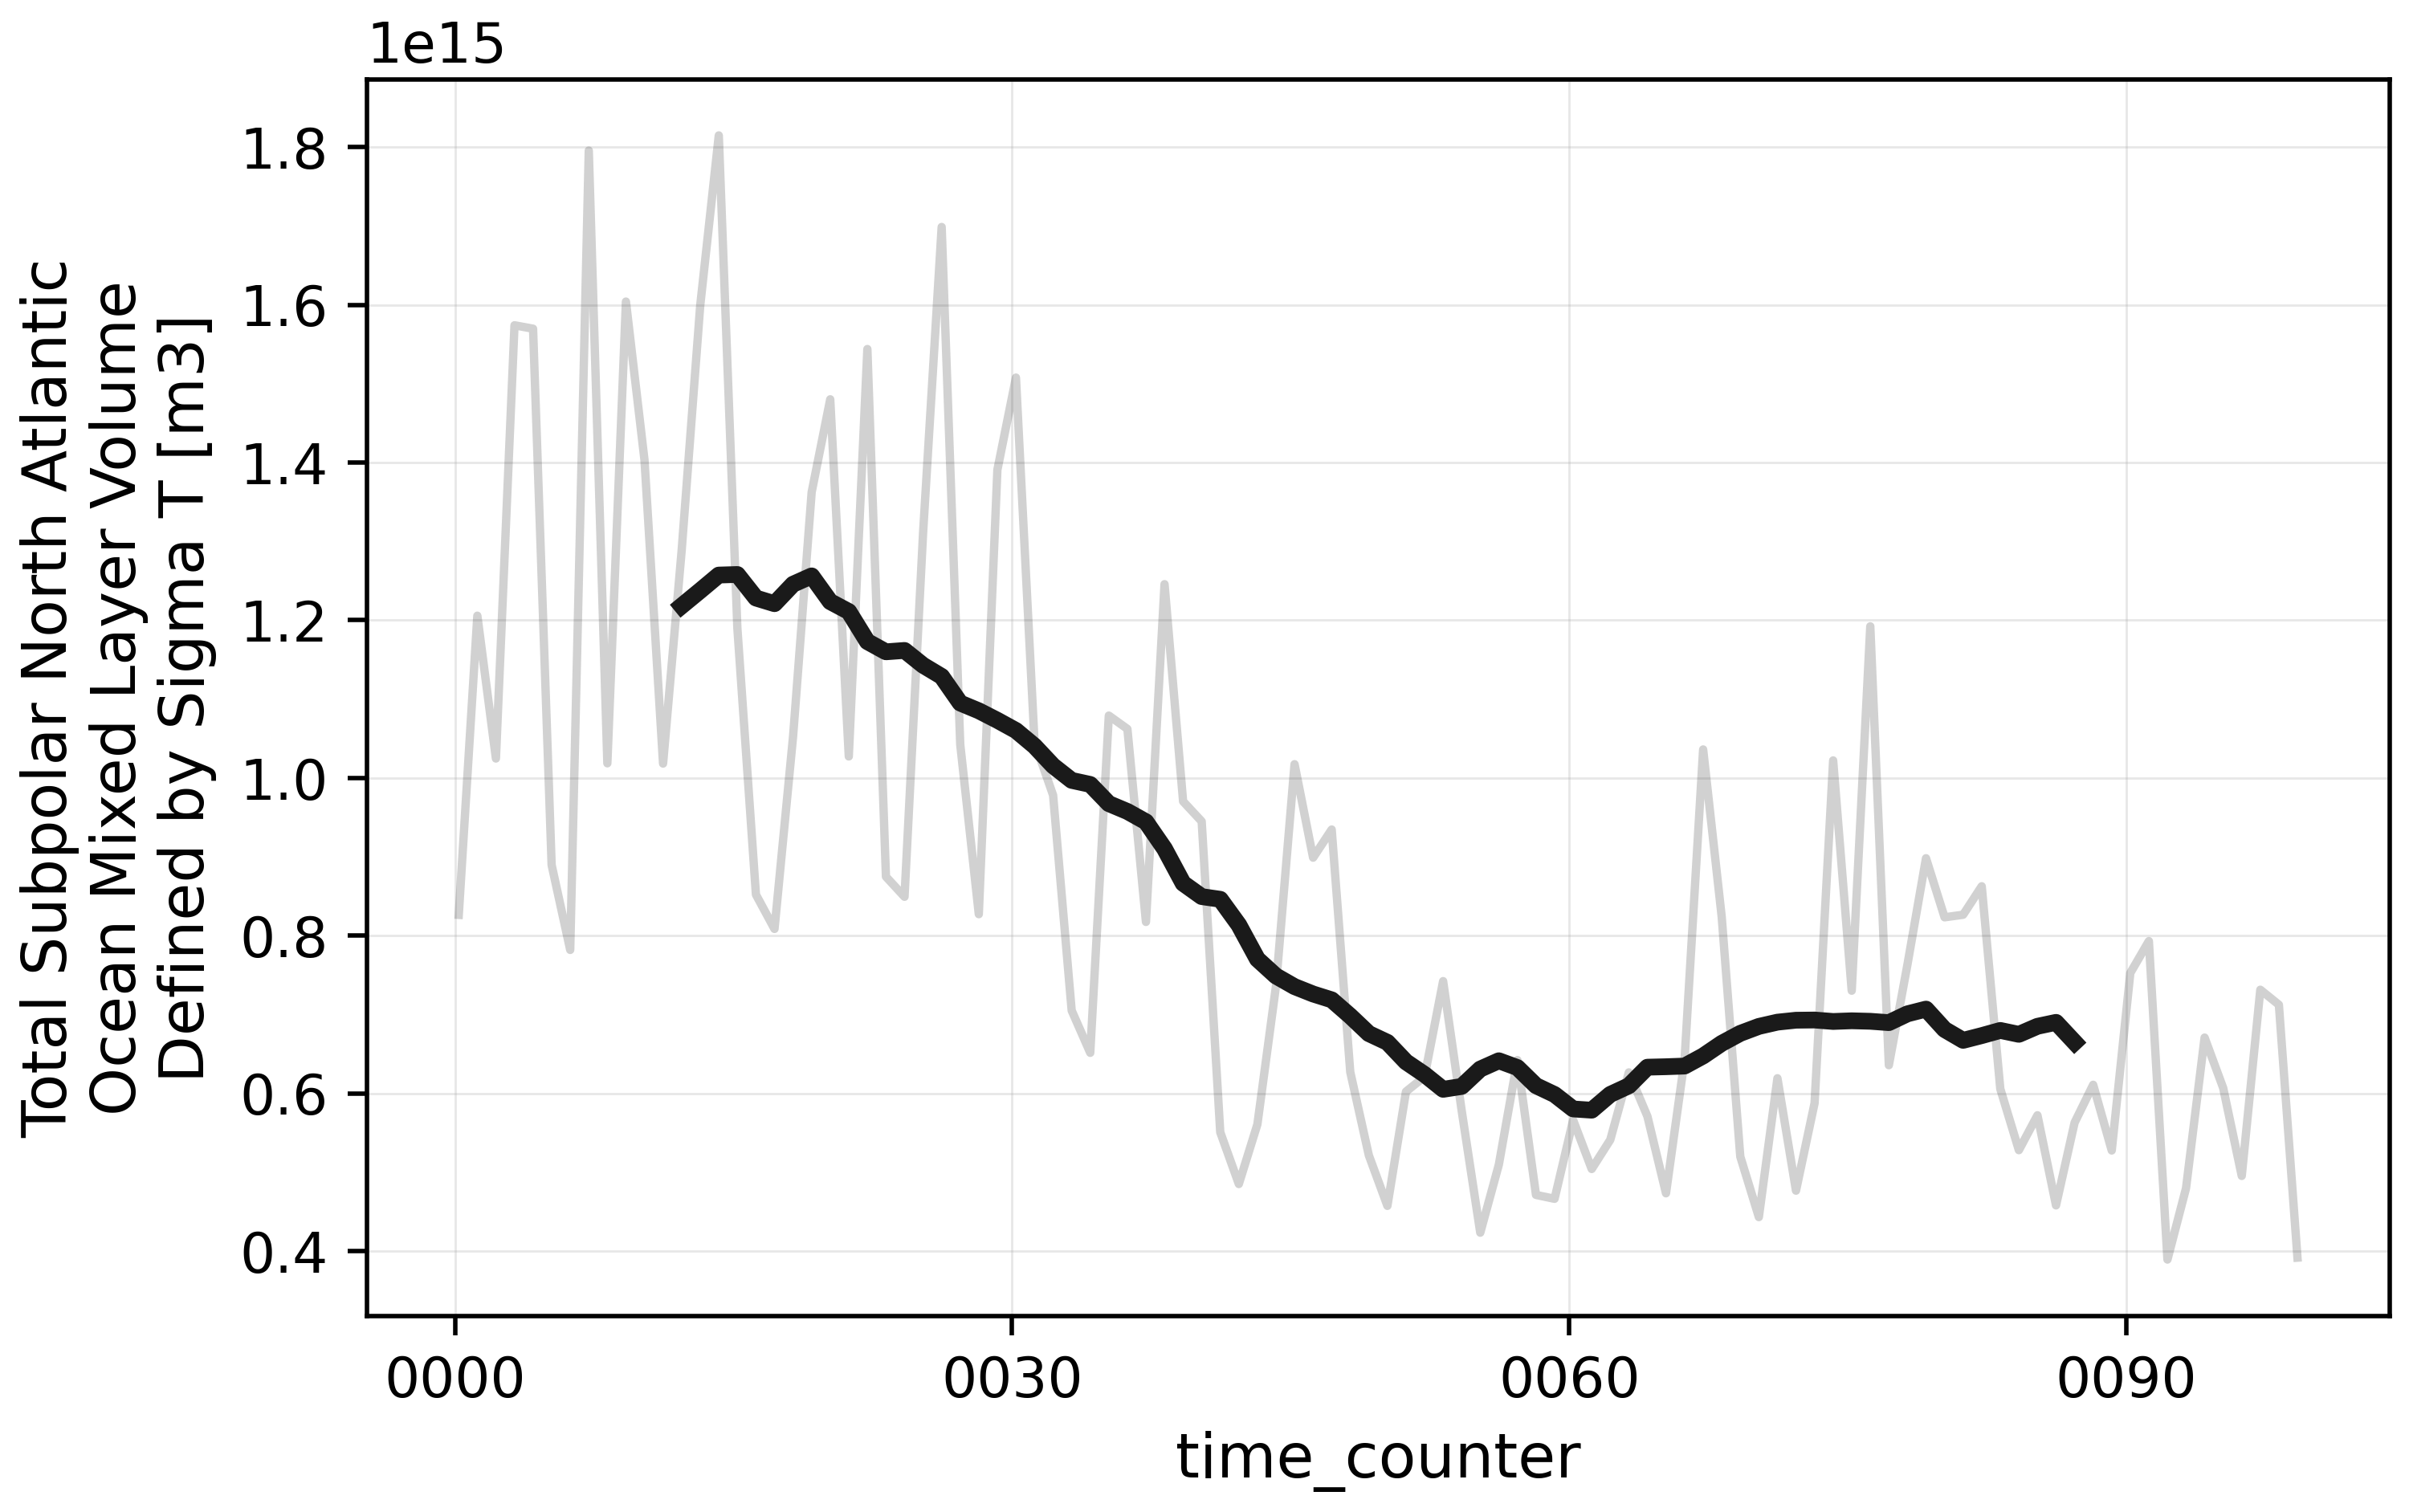

In [7]:
# -- esm-up2p0 -- #
window = 25
plt_var_name = "mlotst_vol_SPNA"

(ds_up2p0[plt_var_name]
 .isel(time_counter=slice(2, 1200, 12))
 .plot(lw=1.5, color="0.1", alpha=0.2, zorder=2)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_up2p0[plt_var_name]
 .isel(time_counter=slice(2, 1200, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="0.1", label="esm-up2p0", zorder=2)
)

In [ ]:
# -- Figure -- #
fig, ax = plt.subplots(figsize=(12, 6))

# Define rolling average window [Yrs]:
window = 25
# Define variable name:
plt_var_name = "mlotst_vol_SPNA"

# -- esm-piControl -- #
# March Monthly Mean MLV:
plt.axhline(ds_piControl[plt_var_name].isel(time_counter=slice(2, None, 12)).mean(dim="time_counter"), lw=2, color="grey")
# 10-year rolling mean MLV:
(ds_piControl[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="grey", label="esm-piControl", zorder=1)
)

# -- esm-up2p0 -- #
(ds_up2p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="0.1", alpha=0.2, zorder=2)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_up2p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="0.1", label="esm-up2p0", zorder=2)
)

# -- esm-up2p0-gwl2p0 -- #
(ds_gwl2p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="mediumseagreen", alpha=0.2, zorder=3)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_gwl2p0['mlotst_vol_SPNA']
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="mediumseagreen", label="esm-up2p0-gwl2p0", zorder=3)
)

# -- esm-up2p0-gwl3p0 -- #
(ds_gwl3p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="goldenrod", alpha=0.2, zorder=2)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_gwl3p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="goldenrod", label="esm-up2p0-gwl3p0", zorder=2)
)

# -- esm-up2p0-gwl4p0 -- #
(ds_gwl4p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="palevioletred", alpha=0.2, zorder=2)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_gwl4p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="palevioletred", label="esm-up2p0-gwl4p0", zorder=2)
)

# Configure Axes:
ax.set_title("UKESM1-2-LL", fontdict={'size': 16, 'weight': 'bold'})
ax.set_xticks([cftime.Datetime360Day(yr, 1, 1) for yr in np.arange(0, 800, 100)], labels=np.arange(0, 800, 100).astype('str'))
ax.set_xlabel("Model Year", fontdict={'size': 13, 'weight': 'bold'}, labelpad=12)
ax.set_ylim([0.2E15, 1.85E15])
ax.set_ylabel("March Mixed Layer Volume [m$^{3}$]", fontdict={'size': 13, 'weight': 'bold'}, labelpad=12)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(ncols=3, fontsize=12)

# Subtle grid styling
ax.grid(which="major", linestyle='-', linewidth=0.4, alpha=0.3)
ax.grid(which="minor", linestyle=':', linewidth=0.3, alpha=0.2)

# Clean spines (modern look)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tight layout
fig.tight_layout()
# Save Figure:
plt.savefig("/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/figures/M26/fig_UKESM1-2-LL_SPNA_mlotst_gwl.png", bbox_inches='tight', dpi=500)


# EC-Earth3-ESM-1

### **EC-Earth3-ESM1:** Mixed Layer Volume

In [ ]:
# -- Define filepaths -- #
ecearth_dir = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/SMHI/mlotst"
ecearth_siconc_names = "EC-Earth3-ESM-1_*_r1i1p1f1_mlotst_*.nc"

ecearth_mlotst_paths = sorted(glob.glob(f"{ecearth_dir}/{ecearth_siconc_names}"))
ecearth_mlotst_paths = sorted([path for path in ecearth_mlotst_paths if '-dn' not in path])
ecearth_mlotst_paths


In [ ]:
time_coder = xr.coders.CFDatetimeCoder(time_unit="s")

# -- Pre-Processing esm-piControl -- #
ds_piControl = xr.open_dataset(ecearth_mlotst_paths[1], decode_times=time_coder)

# -- Pre-Processing esm-up2p0 -- #
ds_up2p0 = xr.open_dataset(ecearth_mlotst_paths[-1], decode_times=time_coder)

# -- Pre-Processing esm-gwl[1.5,2,3,4,5,6] -- #
ds_gwl1p5 = xr.open_dataset(ecearth_mlotst_paths[2], decode_times=time_coder)
ds_gwl2p0 = xr.open_dataset(ecearth_mlotst_paths[3], decode_times=time_coder)
ds_gwl3p0 = xr.open_dataset(ecearth_mlotst_paths[4], decode_times=time_coder)
ds_gwl4p0 = xr.open_dataset(ecearth_mlotst_paths[5], decode_times=time_coder)
ds_gwl5p0 = xr.open_dataset(ecearth_mlotst_paths[6], decode_times=time_coder)
ds_gwl6p0 = xr.open_dataset(ecearth_mlotst_paths[7], decode_times=time_coder)

In [ ]:
# -- Figure -- #
fig, ax = plt.subplots(figsize=(12, 6))

# Define rolling average window [Yrs]:
window = 25
# Define variable name:
plt_var_name = "mlotst_vol_SPNA"

# -- esm-piControl -- #
# March Monthly Mean MLV:
plt.axhline(ds_piControl[plt_var_name].isel(time_counter=slice(2, None, 12)).mean(dim="time_counter"), lw=2, color="grey")
# 10-year rolling mean MLV:
(ds_piControl[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="grey", label="esm-piControl", zorder=1)
)

# -- esm-up2p0 -- #
(ds_up2p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="0.1", alpha=0.2, zorder=2)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_up2p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="0.1", label="esm-up2p0", zorder=2)
)

# -- esm-up2p0-gwl2p0 -- #
(ds_gwl2p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="mediumseagreen", alpha=0.2, zorder=3)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_gwl2p0['mlotst_vol_SPNA']
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="mediumseagreen", label="esm-up2p0-gwl2p0", zorder=3)
)

# -- esm-up2p0-gwl3p0 -- #
(ds_gwl3p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="goldenrod", alpha=0.2, zorder=2)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_gwl3p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="goldenrod", label="esm-up2p0-gwl3p0", zorder=2)
)

# -- esm-up2p0-gwl4p0 -- #
(ds_gwl4p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="palevioletred", alpha=0.2, zorder=2)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_gwl4p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="palevioletred", label="esm-up2p0-gwl4p0", zorder=2)
)

# Configure Axes:
# ax.set_title("(b) EC-Earth3-ESM-1: Subpolar North Atlantic Mixed Layer Volume", fontdict={'size': 16, 'weight': 'bold'})
ax.set_xticks([cftime.Datetime360Day(yr, 1, 1) for yr in np.arange(1850, 2500, 100)], labels=np.arange(0, 650, 100).astype('str'))
ax.set_xlabel("Model Year", fontdict={'size': 13, 'weight': 'bold'}, labelpad=12)
ax.set_ylim([0.2E15, 2.45E15])
ax.set_ylabel("March Mixed Layer Volume [m$^{3}$]", fontdict={'size': 13, 'weight': 'bold'}, labelpad=12)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(ncols=3, fontsize=12)

# Subtle grid styling
ax.grid(which="major", linestyle='-', linewidth=0.4, alpha=0.3)
ax.grid(which="minor", linestyle=':', linewidth=0.3, alpha=0.2)

# Clean spines (modern look)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tight layout
fig.tight_layout()
# Save Figure:
plt.savefig("/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/figures/M26/fig_EC-Earth3-ESM1-2_SPNA_mlotst_gwl.png", bbox_inches='tight', dpi=500)


# IPSL-CM6-ESMCO2

### **IPSL-CM6-ESMCO2:** Mixed Layer Volume

In [ ]:
# -- Define filepaths -- #
ipsl_dir = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/data/IPSL/mlotst"
ipsl_fnames = "IPSL-CM6-ESMCO2_*_r1i1p3f1_mlotst_*.nc"

ipsl_mlotst_paths = sorted(glob.glob(f"{ipsl_dir}/{ipsl_fnames}"))
ipsl_mlotst_paths = sorted([path for path in ipsl_mlotst_paths if '-dn' not in path])
ipsl_mlotst_paths


In [ ]:
time_coder = xr.coders.CFDatetimeCoder(time_unit="s")

# -- Pre-Processing esm-piControl -- #
ds_piControl = xr.open_dataset(ipsl_mlotst_paths[1], decode_times=time_coder).sel(time_counter=slice('1850', None))

# -- Pre-Processing esm-up2p0 -- #
ds_up2p0 = xr.open_dataset(ipsl_mlotst_paths[-1], decode_times=time_coder)

# -- Pre-Processing esm-gwl[2,3,4] -- #
ds_gwl2p0 = xr.open_dataset(ipsl_mlotst_paths[3], decode_times=time_coder)
ds_gwl3p0 = xr.open_dataset(ipsl_mlotst_paths[4], decode_times=time_coder)
ds_gwl4p0 = xr.open_dataset(ipsl_mlotst_paths[5], decode_times=time_coder)


In [ ]:
# -- Figure -- #
fig, ax = plt.subplots(figsize=(12, 6))

# Define rolling average window [Yrs]:
window = 25
# Define variable name:
plt_var_name = "mlotst_vol_SPNA"

# -- esm-piControl -- #
# March Monthly Mean MLV:
plt.axhline(ds_piControl[plt_var_name].isel(time_counter=slice(2, None, 12)).mean(dim="time_counter"), lw=2, color="grey")
# 10-year rolling mean MLV:
(ds_piControl[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="grey", label="esm-piControl", zorder=1)
)

# -- esm-up2p0 -- #
(ds_up2p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="0.1", alpha=0.2, zorder=2)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_up2p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="0.1", label="esm-up2p0", zorder=2)
)

# -- esm-up2p0-gwl2p0 -- #
(ds_gwl2p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="mediumseagreen", alpha=0.2, zorder=3)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_gwl2p0['mlotst_vol_SPNA']
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="mediumseagreen", label="esm-up2p0-gwl2p0", zorder=3)
)

# -- esm-up2p0-gwl3p0 -- #
(ds_gwl3p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="goldenrod", alpha=0.2, zorder=2)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_gwl3p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="goldenrod", label="esm-up2p0-gwl3p0", zorder=2)
)

# -- esm-up2p0-gwl4p0 -- #
(ds_gwl4p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .plot(lw=1.5, color="palevioletred", alpha=0.2, zorder=2)
)
# March Monthly Mean MLV 10-year rolling mean MLV:
(ds_gwl4p0[plt_var_name]
 .isel(time_counter=slice(2, None, 12))
 .rolling(time_counter=window, center=True).mean()
 .plot(lw=3, color="palevioletred", label="esm-up2p0-gwl4p0", zorder=2)
)

# Configure Axes:
# ax.set_title("(c) IPSL-CM6-ESMCO2: Subpolar North Atlantic Mixed Layer Volume", fontdict={'size': 16, 'weight': 'bold'})
ax.set_xticks([cftime.Datetime360Day(yr, 1, 1) for yr in np.arange(1850, 2500, 100)], labels=np.arange(0, 650, 100).astype('str'))
ax.set_xlabel("Model Year", fontdict={'size': 13, 'weight': 'bold'}, labelpad=12)
ax.set_ylim([0.2E15, 1.75E15])
ax.set_ylabel("March Mixed Layer Volume [m$^{3}$]", fontdict={'size': 13, 'weight': 'bold'}, labelpad=12)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(ncols=3, fontsize=12)

# Subtle grid styling
ax.grid(which="major", linestyle='-', linewidth=0.4, alpha=0.3)
ax.grid(which="minor", linestyle=':', linewidth=0.3, alpha=0.2)

# Clean spines (modern look)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tight layout
fig.tight_layout()
# Save Figure:
plt.savefig("/g100_work/optim_IAC/research/noc/otooth/OptimESM/WP5/figures/M26/fig_IPSL-CM6-ESMCO2_SPNA_mlotst_gwl.png", bbox_inches='tight', dpi=500)
